The following code below aims to provide an answer to four questions laid out by 'Turtle Games', our data analysis client.

A. Can we use descriptive statistics to provide insights into the suitability of the loyalty points data to create predictive models (e.g. normal distribution, skewness, or kurtosis) to justify the answer.
1. How do customers engage with and accumulate loyalty points?
2. How can customers be segmented into groups, and which groups can be targeted by the marketing department?
3. How can text data (e.g. social data such as customer reviews) be used to inform marketing campaigns and make improvements to the business?

*For easier navigation through the sheet, each question/section has been made collapsible*

# 1. How do customers engage with and accumulate loyalty points?

For this question, it is important to distinguish the meaning of 'engage'. One might assume that to find engagement, looking within the reviews would be a sure-start, to see what customers might have to say about them. A quick ctrl+f within the csv file leads us to see that there is, in fact, no mention of either keyword 'loyal' or 'loyalty' and, in turn, no 'loyalty points'.
So how do we understand this question? 
Well, as there is no mention by customers of the loyalty point system, nor from Turtle Games of the purpose or interaction potential, it is best to understand it not as a *direct* engagement with the loyalty points themselves, but rather to approach it as: how does who and what the customer is *affect* how these points are gathered. I.e., the engagement isn't voluntary or overt; rather x and y factor leads to more 'engagement' from a and b customer.

So, the initial step I have decided to take is to assess each factor/variable against the loyalty points metric with linear regression, to give a clearer picture from an isolated viewpoint, then with Multiple Linear Regression for a more holistic view, to build a clearer picture of how the factors come together to affect point accumulation and engagement. 



Before we can get started with this, we have to get a sense of the data; clean and adjust if necessary.

In [1]:
import os
os.chdir("/Users/danieldechalons/LSE Data Analysis Course/Course Section 3/Assignment ")

In [2]:
import os
os.getcwd()

'/Users/danieldechalons/LSE Data Analysis Course/Course Section 3/Assignment '

In [3]:
# Install the necessary module.
!pip install scipy

# Import the necessary libraries, packages, and modules.
# Data analysis:
import numpy as np  
import pandas as pd 

# Linear regression:
import sklearn
import statsmodels.api as sm 

# Visualisation:
import matplotlib.pyplot as plt 
import seaborn as sns

# Import the turtle_reviews.csv file.
reviews = pd.read_csv('turtle_reviews.csv') 

# Print the DataFrame.
print(reviews.head())
print(reviews.info())
reviews.describe()

   gender  age  remuneration (k£)  spending_score (1-100)  loyalty_points  \
0    Male   18              12.30                      39             210   
1    Male   23              12.30                      81             524   
2  Female   22              13.12                       6              40   
3  Female   25              13.12                      77             562   
4  Female   33              13.94                      40             366   

  education language platform  product  \
0  graduate       EN      Web      453   
1  graduate       EN      Web      466   
2  graduate       EN      Web      254   
3  graduate       EN      Web      263   
4  graduate       EN      Web      291   

                                              review  \
0  When it comes to a DM's screen, the space on t...   
1  An Open Letter to GaleForce9*:\n\nYour unpaint...   
2  Nice art, nice printing.  Why two panels are f...   
3  Amazing buy! Bought it as a gift for our new d...   
4  A

,age,remuneration (k£),spending_score (1-100),loyalty_points,product
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,39.495000,48.079060,50.000000,1578.032000,4320.521500
std,13.573212,23.123984,26.094702,1283.239705,3148.938839
min,17.000000,12.300000,1.000000,25.000000,107.000000
25%,29.000000,30.340000,32.000000,772.000000,1589.250000
50%,38.000000,47.150000,50.000000,1276.000000,3624.000000
75%,49.000000,63.960000,73.000000,1751.250000,6654.000000
max,72.000000,112.340000,99.000000,6847.000000,11086.000000


In [4]:
# Check for Nulls.
reviews.isnull().values.any()

False

In [5]:
# Copy the data frame.
turtle_reviews_clean = reviews.copy()

# Remove redundant columns.
turtle_reviews_clean.drop(columns = ['language', 'platform'], inplace=True)

# Rename more appropriately.
turtle_reviews_clean.rename(columns = {'remuneration (k£)':'remuneration', 'spending_score (1-100)':'spending_score'}, inplace = True)

# Print the data Frame.
turtle_reviews_clean

,gender,age,remuneration,spending_score,loyalty_points,education,product,review,summary
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap
...,...,...,...,...,...,...,...,...,...
1995,Female,37,84.46,69,4031,PhD,977,The perfect word game for mixed ages (with Mom...,The perfect word game for mixed ages (with Mom
1996,Female,43,92.66,8,539,PhD,979,Great game. Did not think I would like it whe...,Super fun
1997,Male,34,92.66,91,5614,graduate,1012,Great game for all.........\nKeeps the mind ni...,Great Game
1998,Male,34,98.40,16,1048,PhD,1031,fun game!,Four Stars


In [6]:
# Save as a CSV into current directory.
turtle_reviews_clean.to_csv('turtle_reviews_clean.csv')

# Re-import the file.
reviews_clean = pd.read_csv('turtle_reviews_clean.csv') 

# Print the DataFrame and sense check.
print(reviews_clean.head())
print(reviews_clean.info())
reviews_clean.describe()

   Unnamed: 0  gender  age  remuneration  spending_score  loyalty_points  \
0           0    Male   18         12.30              39             210   
1           1    Male   23         12.30              81             524   
2           2  Female   22         13.12               6              40   
3           3  Female   25         13.12              77             562   
4           4  Female   33         13.94              40             366   

  education  product                                             review  \
0  graduate      453  When it comes to a DM's screen, the space on t...   
1  graduate      466  An Open Letter to GaleForce9*:\n\nYour unpaint...   
2  graduate      254  Nice art, nice printing.  Why two panels are f...   
3  graduate      263  Amazing buy! Bought it as a gift for our new d...   
4  graduate      291  As my review of GF9's previous screens these w...   

                                             summary  
0  The fact that 50% of this space is

,Unnamed: 0,age,remuneration,spending_score,loyalty_points,product
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,999.500000,39.495000,48.079060,50.000000,1578.032000,4320.521500
std,577.494589,13.573212,23.123984,26.094702,1283.239705,3148.938839
min,0.000000,17.000000,12.300000,1.000000,25.000000,107.000000
25%,499.750000,29.000000,30.340000,32.000000,772.000000,1589.250000
50%,999.500000,38.000000,47.150000,50.000000,1276.000000,3624.000000
75%,1499.250000,49.000000,63.960000,73.000000,1751.250000,6654.000000
max,1999.000000,72.000000,112.340000,99.000000,6847.000000,11086.000000


### A. Can we use descriptive statistics to provide insights into the suitability of the loyalty points data to create predictive models (e.g. normal distribution, skewness, or kurtosis) to justify the answer.

In [7]:
from scipy.stats import skew, kurtosis

# Evaluate only the numeric value columns.
numeric = reviews_clean.select_dtypes (include='number')  # Only integers/floats

# Calculate skewness.
skewness = numeric.apply(skew, bias = False) # Set Bias = False.
print("Skewness:")
print(skewness)

# Calculate kurtosis.
kurtosis = numeric.apply(kurtosis, bias = False) # Set Bias = False.
print("\nKurtosis:")
print(kurtosis)

Skewness:
Unnamed: 0        0.000000
age               0.609301
remuneration      0.413152
spending_score   -0.041648
loyalty_points    1.464793
product           0.586924
dtype: float64

Kurtosis:
Unnamed: 0       -1.200000
age              -0.188543
remuneration     -0.406067
spending_score   -0.888889
loyalty_points    1.716115
product          -0.771425
dtype: float64


Now, to assess the above, ignoring the 'Unnamed' and the 'product' columns.

With age, we have a moderate skew and , fine not to normalise.
With Remuneration, there is low skewness.
Spending score has virtually no skew at less than 0.1; it is normally distributed.
loyalty points is at 1.4 skew and 1.7 kurtosis, so has heavy tails and is highly skewed and will need to be normalised. by applying a log transformation.

The below code aims to give a visual picture of the skewness and kurtosis so that it is easier to interpret. Variations have been inserted into the report.

In [8]:
reviews_clean["log_loyalty_points"] = np.log1p(reviews_clean["loyalty_points"])

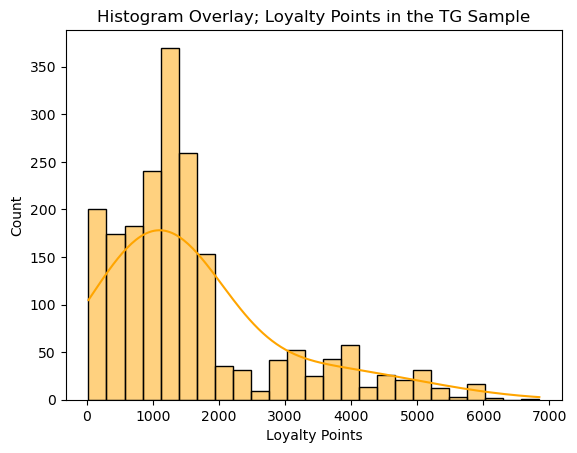

In [9]:
# Visualising the skew and kurtosis of the data. (Variable changed here and inserted into report).

x = sns.histplot(
   reviews_clean["loyalty_points"],
   kde=True,
   kde_kws=dict(bw_adjust=3),
   bins=25,
   color = "orange"
)

plt.title("Histogram Overlay; Loyalty Points in the TG Sample")
plt.xlabel("Loyalty Points");

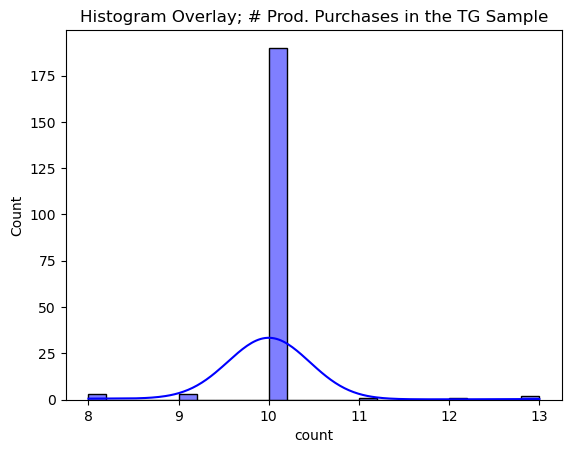

In [10]:
# Then products can be done separately by doing a count.
# Is this really showing anything meaningful?
# How can this be used for a deeper look?

x = sns.histplot(
   reviews_clean["product"].value_counts(),
   kde=True,
   kde_kws=dict(bw_adjust=3),
   bins=25,
   color = "blue"
)

plt.title("Histogram Overlay; # Prod. Purchases in the TG Sample");

#### Linear Regression

In [11]:
# Define the dependent variable.
y = reviews_clean['loyalty_points'].values.reshape(-1, 1) 

# Define the independent variable.
x = reviews_clean['remuneration'].values.reshape(-1, 1)

In [12]:
# Import the necessary package.
from sklearn.linear_model import LinearRegression

# Specify the model.
lm = LinearRegression()

# Fit the model.
lm.fit(x, y) 

LinearRegression()

In [13]:
# Import the sklearn module.
from sklearn.model_selection import train_test_split 

# Create  the subset (50/50); 
# Control the shuffling/avoid variation in values between variables.
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    train_size=0.5,
                                                    random_state=100)

In [14]:
# Fit the model once again with the train data

lm.fit(x_train, y_train)

LinearRegression()

In [15]:
# Predict the training set values.
y_pred = lm.predict(x_train) 

# View the output.
y_pred

array([[1975.35531635],
       [ 740.41971205],
       [ 740.41971205],
       [ 418.26259788],
       [2324.3588567 ],
       [1921.66246399],
       [2646.51597087],
       [2002.20174253],
       [2109.58744725],
       [ 740.41971205],
       [2297.51243052],
       [1438.42679274],
       [1572.65892364],
       [2753.90167559],
       [2082.74102107],
       [ 552.49472878],
       [ 445.10902406],
       [1169.96253094],
       [3210.29092066],
       [1438.42679274],
       [ 740.41971205],
       [1250.50180948],
       [2700.20882323],
       [ 659.88043351],
       [2163.28029962],
       [2297.51243052],
       [1841.12318545],
       [1894.81603781],
       [1223.6553833 ],
       [1948.50889017],
       [1143.11610476],
       [1438.42679274],
       [1143.11610476],
       [1035.73040003],
       [1438.42679274],
       [2351.20528288],
       [1062.57682621],
       [ 498.80187642],
       [2619.66954468],
       [1223.6553833 ],
       [ 498.80187642],
       [1304.194

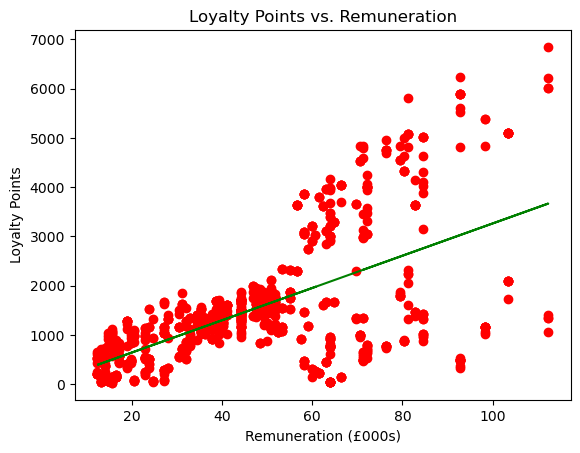

In [16]:
# Create a scatterplot with a regression line.
plt.scatter(x_train, y_train, color = 'red')  
plt.plot(x_train, y_pred, color = 'green')

# Set the title and legends for the graph.  
plt.title("Loyalty Points vs. Remuneration")
plt.xlabel("Remuneration (£000s)")
plt.ylabel("Loyalty Points") 

# Print the graph. 
plt.show()

### Multiple Linear Regression

In [17]:
import statsmodels.api as sm
from sklearn import datasets 
import numpy as np
from sklearn import linear_model
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
import sklearn
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Note: Indicates situations that aren’t necessarily exceptions.
import warnings  
warnings.filterwarnings('ignore')

In [18]:
# Define the dependent variable.
y = reviews_clean['loyalty_points']  

# Define the independent variable.
X = reviews_clean[['spending_score', 'remuneration']]

In [19]:
# Fit the regression model.
mlr = linear_model.LinearRegression()
mlr.fit(X, y)

LinearRegression()

In [20]:
# Call the predictions for X (array).
mlr.predict(X)

array([ 4.57831319e-01,  1.38195101e+03, -1.05713790e+03, ...,
        4.44147048e+03,  2.16956070e+03,  1.71137682e+03])

In [21]:
# Print the R-squared value.
print("R-squared: ", mlr.score(X,y))  

# Print the intercept.
print("Intercept: ", mlr.intercept_) 

# Print the coefficients.
print("Coefficients:")  

# Map a similar index of multiple containers (to be used as a single entity).
list(zip(X, mlr.coef_))

R-squared:  0.8269134701989259
Intercept:  -1700.3050970144384
Coefficients:


[('spending_score', 32.892694687821006), ('remuneration', 33.97949882180284)]

**The R-Squared value here is very high at 0.827. It is explaing about 83% of the variance in loyalty points based on the chosen variables, i.e., spending score and remuneration are the biggest drivers together for accumulation of loyalty points. Adding age as a variable in the model, we arrive at 84%, only a very marginal increase.**

In [22]:
# Create a variable 'New_Rooms' and define it as 5.7.
New_Rooms = 5.75

# Create 'New_Distance' and define it as 15.2.
New_Distance = 15.2  

# Print the predicted value. 
print ("Predicted Value: \n", mlr.predict([[New_Rooms ,New_Distance]]))

Predicted Value: 
 [-994.68372047]


In [23]:
# Split the data in 'train' (80%) and 'test' (20%) sets.
X_train, X_test, Y_train, Y_test = sklearn.model_selection.train_test_split(X, y,
                                                                            test_size = 0.20,
                                                                            random_state = 5)

In [24]:
# Training the model using the 'statsmodel' OLS library.
# Fit the model with the added constant.
model = sm.OLS(Y_train, sm.add_constant(X_train)).fit()

# Set the predicted response vector.
Y_pred = model.predict(sm.add_constant(X_test)) 

# Call a summary of the model.
print_model = model.summary()

# Print the summary.
print(print_model)

                            OLS Regression Results                            
Dep. Variable:         loyalty_points   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.821
Method:                 Least Squares   F-statistic:                     3665.
Date:                Mon, 13 Oct 2025   Prob (F-statistic):               0.00
Time:                        11:54:09   Log-Likelihood:                -12292.
No. Observations:                1600   AIC:                         2.459e+04
Df Residuals:                    1597   BIC:                         2.461e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const          -1700.3810     40.400    -42.

The above OLS regression results serve to validate our findings and also answer the question *'Can we use descriptive statistics to provide insights into the suitability of the loyalty points data to create predictive models?'* The R Squared number sits at 0.821, explaining 82% of the variance in the model. 

The standard error value is low, indicating good accuracy for predictions.

The results also show that the residuals in the data are essentially normal through the Omnibus skew and kurtosis scores. The Jarque Bera score also reinforces this conclusion.

The durbin watson test shows a number 1.9 which is between 1 and 2 and thus homoscedastic. 

The Cond. No. is showing a number less than 1000, which should suggest low multicollinearity.

In [25]:
# Specify the model.
mlr = LinearRegression()  

# Fit the model. We can only fit the model with the training data set.
mlr.fit(X_train, Y_train)

LinearRegression()

In [26]:
# Call the predictions for X in the train set.
y_pred_mlr = mlr.predict(X_train)  

# Print the predictions.
print("Prediction for train set: {}".format(y_pred_mlr))

Prediction for train set: [ 1218.46660121   618.29301891  2312.04851244 ...  1452.7136095
 -1006.77936277  1203.19986663]


In [27]:
# Call the predictions for X in the test set.
y_pred_mlr = mlr.predict(X_test)  

# Print the predictions.
print("Prediction for test set: {}".format(y_pred_mlr))

Prediction for test set: [ 1.43311406e+03  3.38498142e+03  1.68174774e+03  1.59972741e+03
  1.05209014e+03  1.17026310e+03  3.41036952e+03  1.05209014e+03
  3.25925979e+03  2.23910009e+03 -2.03602914e+02  4.81806858e+02
  1.25121581e+02  1.20319987e+03  1.26907340e+03  1.41158500e+03
  1.19739315e+02  1.56679064e+03  3.16711810e+03  2.23910009e+03
  1.66560094e+03  2.08389444e+03  1.45271361e+03 -6.55239460e+02
  4.41052339e+03  2.99705200e+03  3.41317910e+03  1.56550430e+03
 -7.15730728e+02  1.57819835e+03  1.44645128e+03  4.20816370e+03
  1.32804143e+03  3.89839558e+03  1.23677981e+03  1.99022952e+03
 -1.11461224e+02  6.96217428e+02  2.16117568e+03  8.16556791e+02
  1.73749992e+03  9.49827093e+02  1.03313377e+03  1.56679064e+03
 -8.46834623e+02  1.50027394e+03  1.21332123e+03  1.67162638e+03
 -1.06188836e+03  1.61651738e+03  1.53063802e+03 -1.07803516e+03
  3.01793790e+03  1.60703919e+03 -2.52956378e+00  1.59908424e+03
  1.41287134e+03  1.21846660e+03  1.40877542e+03  3.93735779e+03


In [28]:
# Print the R-squared value.
print(mlr.score(X_test, Y_test)*100)

84.27307474340161


In [29]:
# Add a constant.
x_temp = sm.add_constant(X_train)  

# Create an empty DataFrame. 
vif = pd.DataFrame() 

# Calculate the 'vif' for each value.
vif["VIF Factor"] = [variance_inflation_factor(x_temp.values, 
                                               i) for i in range(x_temp.values.shape[1])]  


# Create the feature columns.
vif['features'] = x_temp.columns  

# Print the values to two decimal points.
print(vif.round(2))

   VIF Factor        features
0        9.45           const
1        1.00  spending_score
2        1.00    remuneration


In [30]:
# Call the ‘metrics.mean_absolute_error’ function.  
print('Mean Absolute Error (Final):', metrics.mean_absolute_error(Y_test, Y_pred))  

# Call the ‘metrics.mean_squared_error’ function.
print('Mean Square Error (Final):', metrics.mean_squared_error(Y_test, Y_pred))

Mean Absolute Error (Final): 446.6705634924689
Mean Square Error (Final): 323161.1161134791


**relative to our data set the MAE here is relatively low and further validates the accuracy of the model.**

### Decision Tree Regressor

In [31]:
# Import the necessary libraries, packages, and modules.
import pandas as pd 
import numpy as np 
import scipy as scp
import sklearn
import statsmodels.api as sm  
import math

from sklearn import metrics
from sklearn.model_selection import train_test_split

import warnings  
warnings.filterwarnings('ignore')  

In [32]:
# Specify that the column Loyalty Points 
# should be moved into a separate DataFrame.
turtle_regress = reviews_clean.columns[reviews_clean.columns != 'loyalty_points']  

# Specify 'X' as the independent variables 
# and 'y' as the dependent variable.
X = reviews_clean[turtle_regress]
y = reviews_clean['loyalty_points']
X = pd.get_dummies(X, drop_first=True)

# Split the data training and testing 30/70.
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=42)

# Import the 'DecisionTreeRegressor' class from sklearn.
from sklearn.tree import DecisionTreeRegressor  

# Create the 'DecisionTreeRegressor' class 
# (which has many parameters; input only #random_state=0).
regressor = DecisionTreeRegressor(random_state=42)

# Fit the regressor object to the data set.
regressor.fit(X_train,y_train)

DecisionTreeRegressor(random_state=42)

In [33]:
# Predict the response for the data test.
y_predict = regressor.predict(X_test)  

# Specify to print the MAE and MSE (to evaluate the accuracy of the new model).
print("Mean Absolute Error: ", metrics.mean_absolute_error(y_test, y_predict))
print("Mean Squared Error: ", metrics.mean_squared_error(y_test, y_predict))
# Calculate the RMSE.
print("Root Mean Squared Error: ", 
     math.sqrt(metrics.mean_squared_error(y_test, y_predict)))

Mean Absolute Error:  3.935
Mean Squared Error:  346.035
Root Mean Squared Error:  18.60201601977592


**Random Forest Regressor**

In [34]:
# Import all necessary libraries.
import pandas as pd 
import numpy as np 
import scipy as scp
import sklearn
import statsmodels.api as sm  

from sklearn.model_selection import train_test_split
from sklearn import metrics 

import warnings  
warnings.filterwarnings('ignore')

In [35]:
# Specify that the column loyalty_points
# should be moved into a separate DataFrame.
turtle_regress = reviews_clean.columns[reviews_clean.columns != 'loyalty_points']  

# Specify 'X' as the independent variables 
# and 'y' as the dependent variable.
X = reviews_clean[turtle_regress]
y = reviews_clean['loyalty_points']
X = pd.get_dummies(X, drop_first=True)

# Split the data training and testing 30/70.
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)

# Import the random forest regressor class.
from sklearn.ensemble import RandomForestRegressor 

# Create the regressor object.
regressor = RandomForestRegressor(n_estimators=5, 
                                  random_state=42, 
                                  n_jobs=2)

# Fit the regressor to the data set, and predict the y variable.
regressor.fit(X_train, y_train)

RandomForestRegressor(n_estimators=5, n_jobs=2, random_state=42)

In [36]:
# Predict the response for the data test.
y_predict = regressor.predict(X_test)  

# Specify to print the MAE and MSE (to evaluate the accuracy of the new model).
print("Mean Absolute Error: ", metrics.mean_absolute_error(y_test, y_predict))
print("Mean Squared Error: ", metrics.mean_squared_error(y_test, y_predict))
# Calculate the RMSE.
print("Root Mean Squared Error: ", 
     math.sqrt(metrics.mean_squared_error(y_test, y_predict)))

Mean Absolute Error:  3.1939999999999924
Mean Squared Error:  120.31659999999987
Root Mean Squared Error:  10.968892377993317


# 2. How can customers be segmented into groups, and which groups can be targeted by the marketing department?

### K-Means Clustering

In [37]:
# Drop unnecessary columns.
reviews_cluster = reviews_clean.drop(columns=['Unnamed: 0', 'education', 'product', 'review', 'summary'])

# Encode gender as numeric.
reviews_cluster['gender'] = reviews_cluster['gender'].map({'Male': 0, 'Female': 1})

# Display a summary of the numeric variables and column names.
print(reviews_cluster.columns)
reviews_cluster.describe()

Index(['gender', 'age', 'remuneration', 'spending_score', 'loyalty_points',
       'log_loyalty_points'],
      dtype='object')


,gender,age,remuneration,spending_score,loyalty_points,log_loyalty_points
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.560000,39.495000,48.079060,50.000000,1578.032000,6.984150
std,0.496511,13.573212,23.123984,26.094702,1283.239705,1.017051
min,0.000000,17.000000,12.300000,1.000000,25.000000,3.258097
25%,0.000000,29.000000,30.340000,32.000000,772.000000,6.650279
50%,1.000000,38.000000,47.150000,50.000000,1276.000000,7.152268
75%,1.000000,49.000000,63.960000,73.000000,1751.250000,7.468656
max,1.000000,72.000000,112.340000,99.000000,6847.000000,8.831712


In [38]:
# Import Seaborn and Matplotlib.
# from matplotlib import pyplot as plt
# import seaborn as sns

# Create a scatterplot with Seaborn.
# sns.scatterplot(x='lbm',
               # y='bmi',
               # data=df,
               # hue='sex')


# Create a pairplot with Seaborn.
# x = df[['lbm', 'bmi']]

# sns.pairplot(df,
             # vars=x,
             # hue='sex',
             # diag_kind= 'kde') ##

In [39]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [40]:
# Drop unnecessary columns
reviews_cluster = reviews_clean.drop(
    columns=['Unnamed: 0', 'education', 'product', 'review', 'summary']
)

# Encode gender as numeric.
reviews_cluster['gender'] = reviews_cluster['gender'].map({'Male': 0, 'Female': 1})

# Display summary
print(reviews_cluster.columns)
print("\nSummary stats:\n", reviews_cluster.describe())

Index(['gender', 'age', 'remuneration', 'spending_score', 'loyalty_points',
       'log_loyalty_points'],
      dtype='object')

Summary stats:
             gender          age  remuneration  spending_score  loyalty_points  \
count  2000.000000  2000.000000   2000.000000     2000.000000     2000.000000   
mean      0.560000    39.495000     48.079060       50.000000     1578.032000   
std       0.496511    13.573212     23.123984       26.094702     1283.239705   
min       0.000000    17.000000     12.300000        1.000000       25.000000   
25%       0.000000    29.000000     30.340000       32.000000      772.000000   
50%       1.000000    38.000000     47.150000       50.000000     1276.000000   
75%       1.000000    49.000000     63.960000       73.000000     1751.250000   
max       1.000000    72.000000    112.340000       99.000000     6847.000000   

       log_loyalty_points  
count         2000.000000  
mean             6.984150  
std              1.017051  
min          

In [41]:
# Scale the data.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(reviews_cluster)
X_scaled = pd.DataFrame(X_scaled, columns=reviews_cluster.columns)

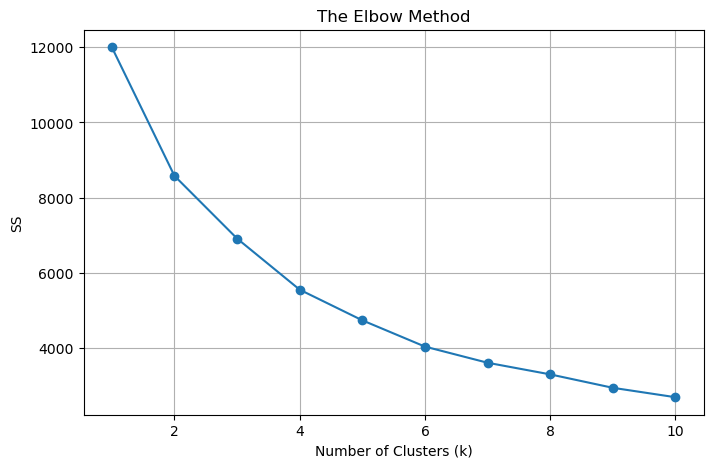

In [42]:
ss = []  # To store inertia (sum of squared distances).
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=500, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    ss.append(kmeans.inertia_)
    
# Plot the elbow method.
plt.figure(figsize=(8, 5))
plt.plot(K_range, ss, marker='o')
plt.title("The Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("SS")
plt.grid(True)
plt.show()

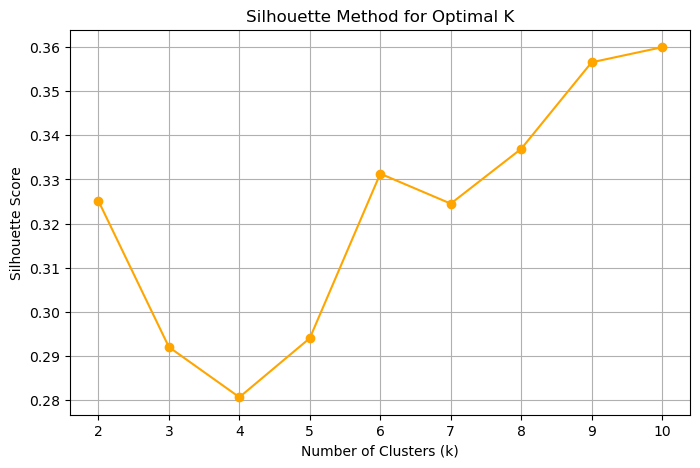

In [43]:
sil = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=500, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    labels = kmeans.labels_
    sil.append(silhouette_score(X_scaled, labels, metric='euclidean'))

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), sil, marker='o', color='orange')
plt.title("Silhouette Method for Optimal K")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

In [44]:
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', max_iter=500, n_init=10, random_state=42)
kmeans_final.fit(X_scaled)

# Add cluster labels to DataFrame
reviews_cluster['Cluster'] = kmeans_final.labels_

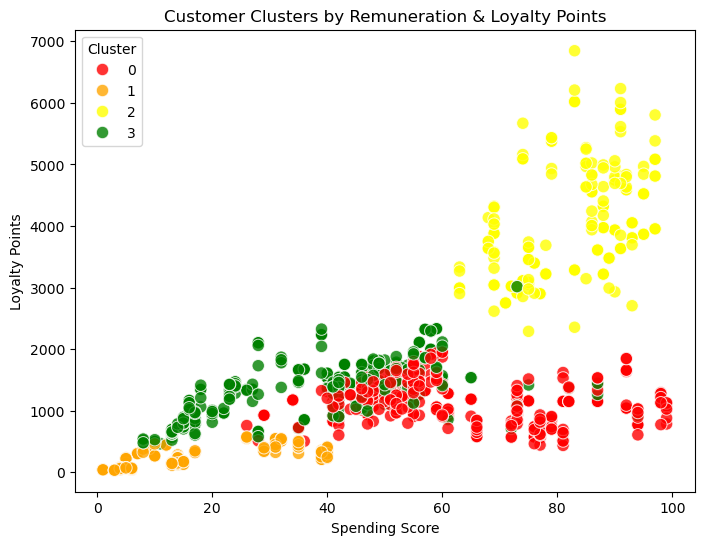

In [45]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=reviews_cluster,
    x='spending_score',
    y='loyalty_points',
    hue='Cluster',
    palette=['red', 'orange', 'yellow', 'green', 'blue', 'indigo'],
    s=80,
    alpha=0.8
)
plt.title("Customer Clusters by Remuneration & Loyalty Points")
plt.xlabel('Spending Score')
plt.ylabel('Loyalty Points')
plt.show()

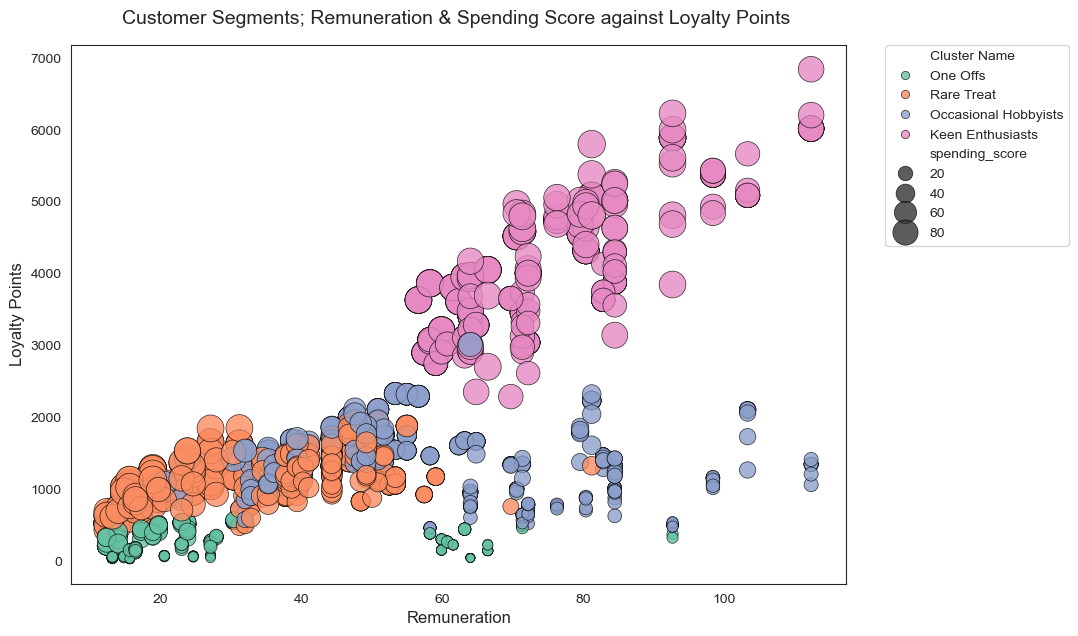

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define cluster names.
cluster_names = {
    0: 'Rare Treat', # Spend is big but not often, lower earners.
    1: 'One Offs', # Purchases made once or twice, maybe gift buyers.
    2: 'Keen Enthusiasts', # Earnings are high, and so is spending.
    3: 'Occasional Hobbyists', # Earnings vary widely, spend per purchase low.
}

# Map numeric cluster labels to names.
reviews_cluster['Cluster Name'] = reviews_cluster['Cluster'].map(cluster_names)

# Set background.
sns.set_style("white")
plt.figure(figsize=(10, 7))

# Create scatterplot.
sns.scatterplot(
    data=reviews_cluster,
    x='remuneration',
    y='loyalty_points',
    hue='Cluster Name',
    size='spending_score',
    sizes=(40, 400),
    alpha=0.8,
    palette='Set2',
    edgecolor='black',
    linewidth=0.5
)

# Add titles and labels.
plt.title("Customer Segments; Remuneration & Spending Score against Loyalty Points ", fontsize=14, pad=15)
plt.xlabel("Remuneration", fontsize=12)
plt.ylabel("Loyalty Points", fontsize=12)

# Adjust key.
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.grid(False)

plt.show()

In [47]:
print("\nNumber of observations per cluster:")
print(reviews_cluster['Cluster'].value_counts())

print("\nCluster Means:")
print(reviews_cluster.groupby('Cluster').mean(numeric_only=True))


Number of observations per cluster:
Cluster
3    714
0    608
2    355
1    323
Name: count, dtype: int64

Cluster Means:
           gender        age  remuneration  spending_score  loyalty_points  \
Cluster                                                                      
0        0.593750  28.759868     33.982796       62.544408     1138.588816   
1        0.529412  40.975232     29.063034       16.136223      242.563467   
2        0.552113  35.501408     73.266423       82.033803     3990.980282   
3        0.549020  49.952381     56.161961       38.710084     1356.661064   

         log_loyalty_points  
Cluster                      
0                  6.994161  
1                  5.182242  
2                  8.267784  
3                  7.152554  


Now we can move onto question 3.

# 3. How can text data (e.g. social data such as customer reviews) be used to inform marketing campaigns and make improvements to the business?

In [48]:
!pip install vaderSentiment --quiet

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [49]:
# Drop missing reviews.
reviews_clean = reviews_clean.dropna(subset=['review'])

In [50]:
sia = SentimentIntensityAnalyzer()

# Apply VADER to each review
sentiment_results = reviews_clean['review'].apply(sia.polarity_scores).apply(pd.Series)

# Combine sentiment results with the original dataset
reviews_sentiment = pd.concat([reviews_clean, sentiment_results], axis=1)

In [51]:
print("\nAverage Sentiment Scores:")
print(reviews_sentiment[['neg', 'neu', 'pos', 'compound']].mean())


Average Sentiment Scores:
neg         0.030980
neu         0.672451
pos         0.296563
compound    0.645715
dtype: float64


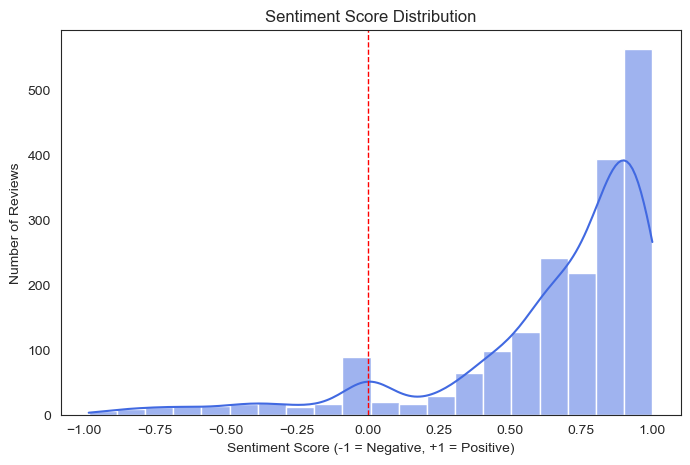

In [52]:
plt.figure(figsize=(8,5))
sns.histplot(reviews_sentiment['compound'], bins=20, kde=True, color='royalblue')
plt.title("Sentiment Score Distribution")
plt.xlabel("Sentiment Score (-1 = Negative, +1 = Positive)")
plt.ylabel("Number of Reviews")
plt.axvline(0, color='red', linestyle='--', linewidth=1)
plt.grid(False)
plt.show()

In [53]:
# Transform data to lowercase.
reviews_clean['review'] = reviews_clean['review'].apply(lambda x: " ".join(x.lower() for x in x.split()))

# Preview the result.
reviews_clean['review'].head()

0    when it comes to a dm's screen, the space on t...
1    an open letter to galeforce9*: your unpainted ...
2    nice art, nice printing. why two panels are fi...
3    amazing buy! bought it as a gift for our new d...
4    as my review of gf9's previous screens these w...
Name: review, dtype: object

In [54]:
# Remove punctuation.
reviews_clean['review'] = reviews_clean['review'].str.replace('[^\w\s]','')

# Preview the result.
reviews_clean['review'].head()

0    when it comes to a dm's screen, the space on t...
1    an open letter to galeforce9*: your unpainted ...
2    nice art, nice printing. why two panels are fi...
3    amazing buy! bought it as a gift for our new d...
4    as my review of gf9's previous screens these w...
Name: review, dtype: object

In [55]:
# Check the number of duplicate values.
reviews_clean.review.duplicated().sum()

32

In [56]:
# Drop duplicates.
review_less_duplicates = reviews_clean.drop_duplicates(subset=['review'])

# Preview data.
review_less_duplicates.reset_index(inplace=True)
review_less_duplicates.head()

,index,Unnamed: 0,gender,age,remuneration,spending_score,loyalty_points,education,product,review,summary,log_loyalty_points
0,0,0,Male,18,12.30,39,210,graduate,453,"when it comes to a dm's screen, the space on t...",The fact that 50% of this space is wasted on a...,5.351858
1,1,1,Male,23,12.30,81,524,graduate,466,an open letter to galeforce9*: your unpainted ...,Another worthless Dungeon Master's screen from...,6.263398
2,2,2,Female,22,13.12,6,40,graduate,254,"nice art, nice printing. why two panels are fi...","pretty, but also pretty useless",3.713572
3,3,3,Female,25,13.12,77,562,graduate,263,amazing buy! bought it as a gift for our new d...,Five Stars,6.333280
4,4,4,Female,33,13.94,40,366,graduate,291,as my review of gf9's previous screens these w...,Money trap,5.905362


In [57]:
# View the shape of the data.
review_less_duplicates.shape

(1968, 12)

In [58]:
# String all the comments together in a single variable.
# Create an empty string variable.
all_reviews = ''
for i in range(review_less_duplicates.shape[0]):
    # Add each comment.
    all_reviews = all_reviews + reviews_clean['review'][i]

In [59]:
# Install WordCloud.
!pip install WordCloud

In [60]:
# Import along with matplotlib and seaborn for visualisation.
from wordcloud import WordCloud 
import matplotlib.pyplot as plt 
import seaborn as sns

In [61]:
# Set the colour palette.
sns.set(color_codes=True)

# Create a WordCloud object.
word_cloud = WordCloud(width = 1600, height = 900, 
                background_color ='white',
                colormap = 'plasma', 
                stopwords = 'none',
                min_font_size = 10).generate(all_reviews)

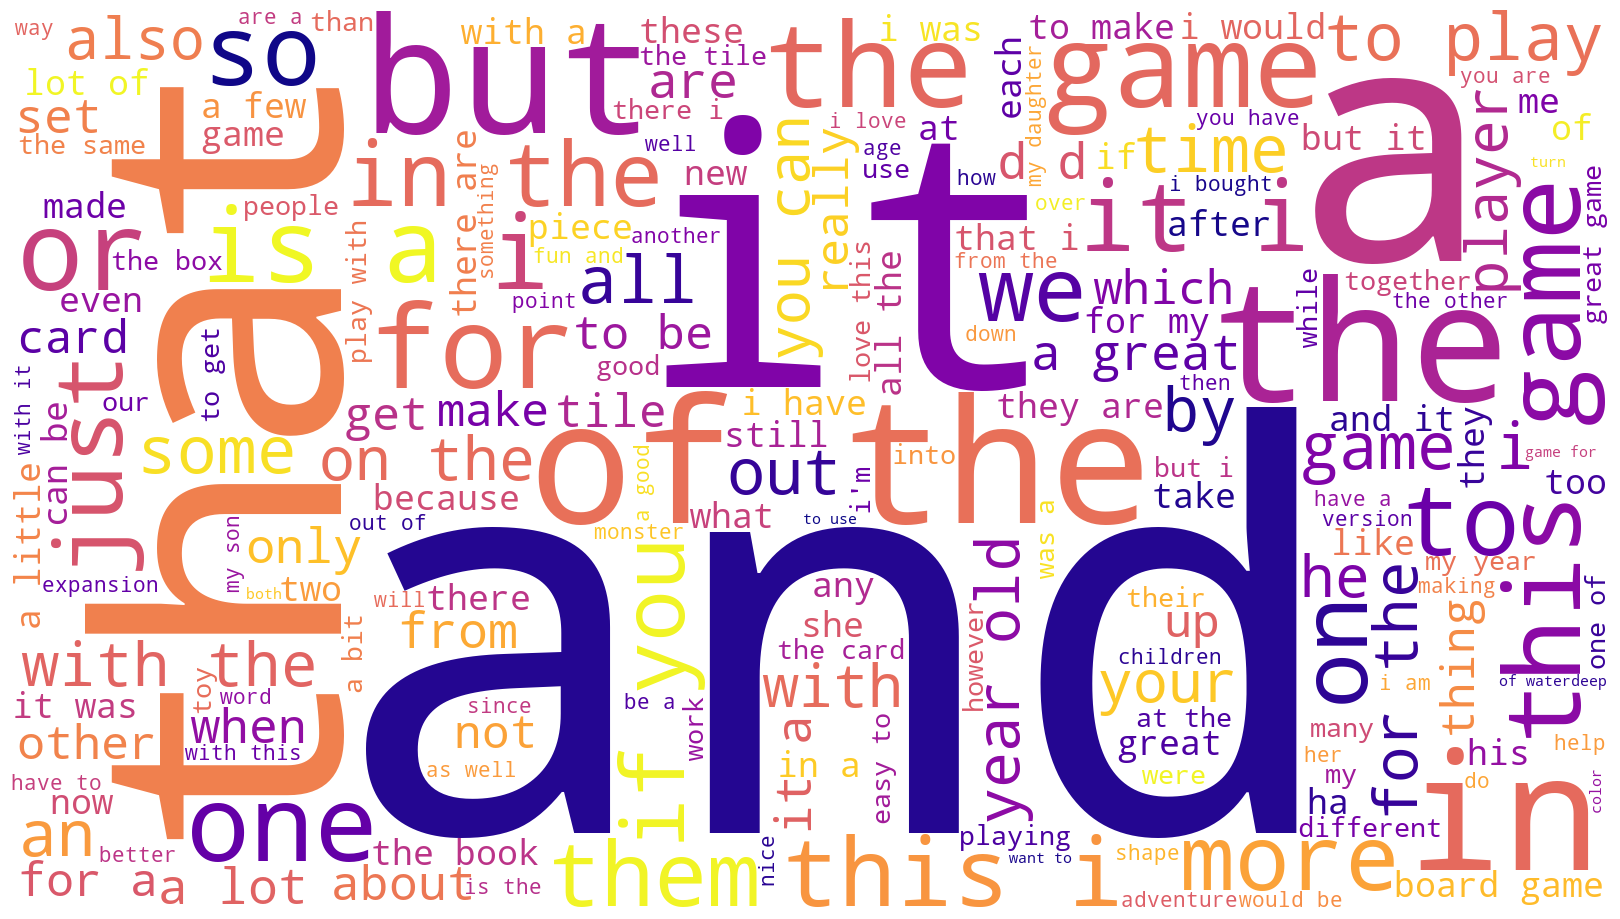

In [62]:
# Plot the WordCloud image.                    
plt.figure(figsize = (16, 9), facecolor = None) 
plt.imshow(word_cloud) 
plt.axis('off') 
plt.tight_layout(pad = 0) 
plt.show()

In [63]:
# Import nltk and download nltk's resources to assist with tokenisation.
import nltk

nltk.download('punkt')
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/danieldechalons/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [64]:
# Tokenise the words.
reviews_clean['tokens'] = reviews_clean['review'].apply(word_tokenize)

# Preview data.
reviews_clean['tokens'].head()

0    [when, it, comes, to, a, dm, 's, screen, ,, th...
1    [an, open, letter, to, galeforce9, *, :, your,...
2    [nice, art, ,, nice, printing, ., why, two, pa...
3    [amazing, buy, !, bought, it, as, a, gift, for...
4    [as, my, review, of, gf9, 's, previous, screen...
Name: tokens, dtype: object

In [65]:
# Define an empty list of tokens.
all_tokens = []

for i in range(reviews_clean.shape[0]):
    # Add each token to the list.
    all_tokens = all_tokens + reviews_clean['tokens'][i]

In [66]:
# Import the FreqDist class.
from nltk.probability import FreqDist

# Calculate the frequency distribution.
fdist = FreqDist(all_tokens)

# Preview data.
fdist

FreqDist({'.': 6472, 'the': 5457, ',': 3793, 'and': 3248, 'a': 3170, 'to': 3164, 'it': 2494, 'of': 2491, 'i': 2345, 'is': 1834, ...})

In [67]:
# Filter out tokens that are neither alphabets nor numbers (to eliminate punctuation marks, etc.).
tokens = [word for word in all_tokens if word.isalnum()]

In [68]:
# Download the stopword list.
nltk.download ('stopwords')
from nltk.corpus import stopwords

# Create a set of English stopwords.
english_stopwords = set(stopwords.words('english'))

# Create a filtered list of tokens without stopwords.
tokens2 = [x for x in tokens if x.lower() not in english_stopwords]

# Define an empty string variable.
tokens2_string = ''

for value in tokens:
    # Add each filtered token word to the string.
    tokens2_string = tokens2_string + value + ' '

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/danieldechalons/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


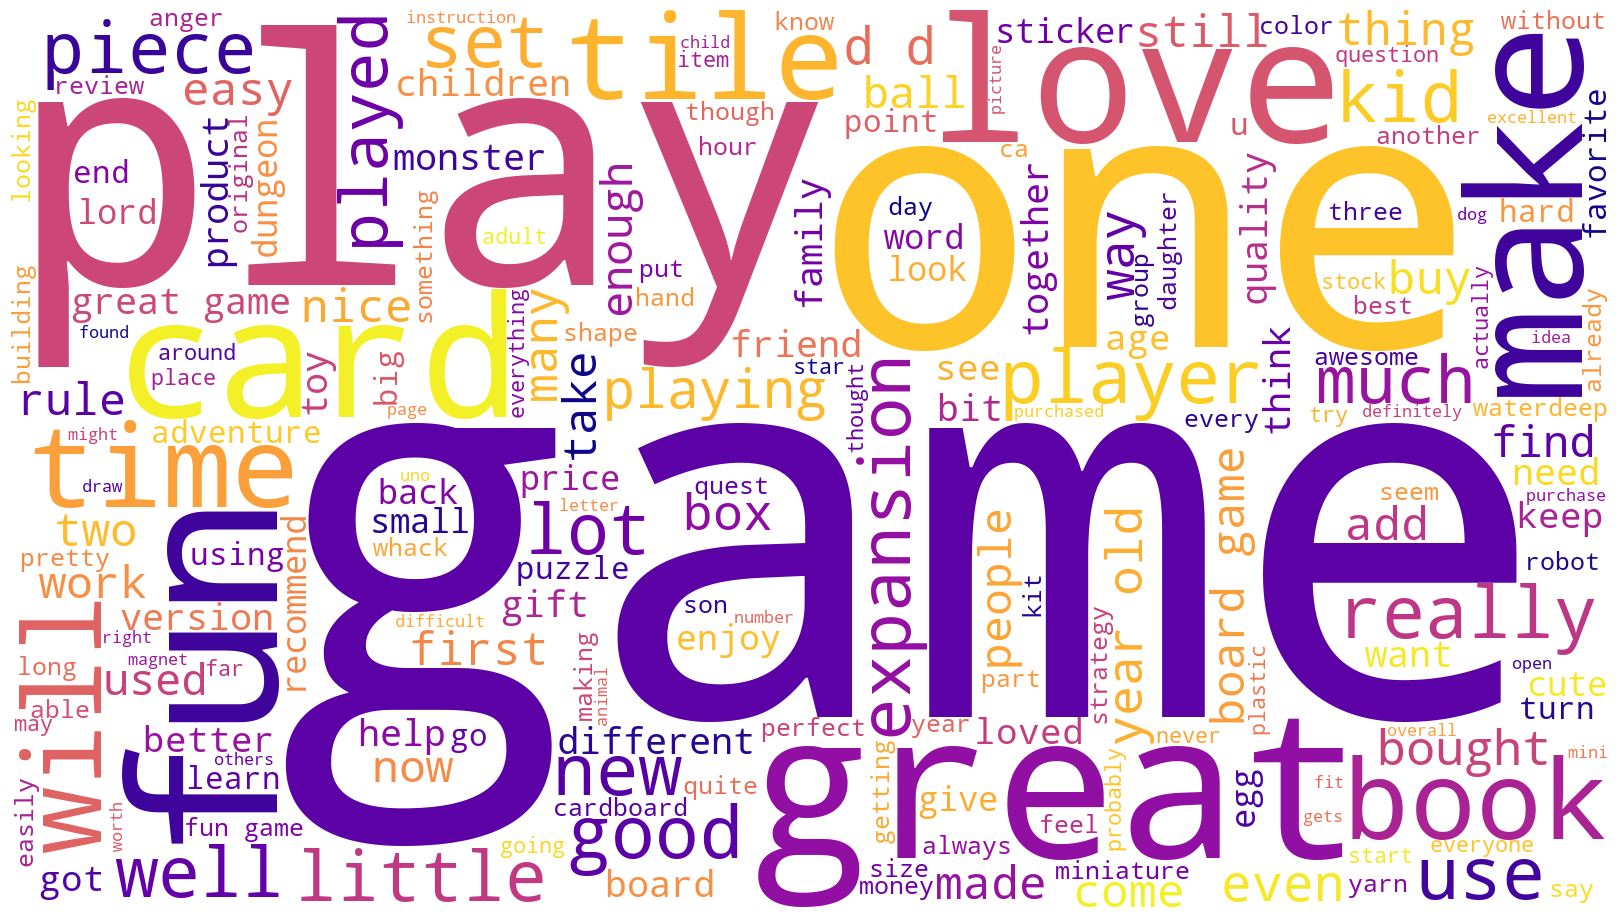

In [69]:
# Create a WordCloud.
wordcloud = WordCloud(width = 1600, height = 900, 
                background_color ='white', 
                colormap='plasma', 
                min_font_size = 10).generate(tokens2_string) 

# Plot the WordCloud image.                        
plt.figure(figsize = (16, 9), facecolor = None) 
plt.imshow(wordcloud) 
plt.axis('off') 
plt.tight_layout(pad = 0) 
plt.show()

In [70]:
# View the frequency distribution.
fdist1 = FreqDist(tokens2)

# Preview the data.
fdist1

FreqDist({'game': 1699, 'great': 596, 'fun': 555, 'one': 532, 'play': 504, 'like': 414, 'love': 332, 'get': 320, 'really': 318, 'cards': 301, ...})

In [71]:
# Import the Counter class.
from collections import Counter

# Generate a DataFrame from Counter.
counts = pd.DataFrame(Counter(tokens2).most_common(15),
                      columns=['Word', 'Frequency']).set_index('Word')

# Preview data.
counts

,Frequency
Word,
game,1699
great,596
fun,555
one,532
play,504
like,414
love,332
get,320
really,318


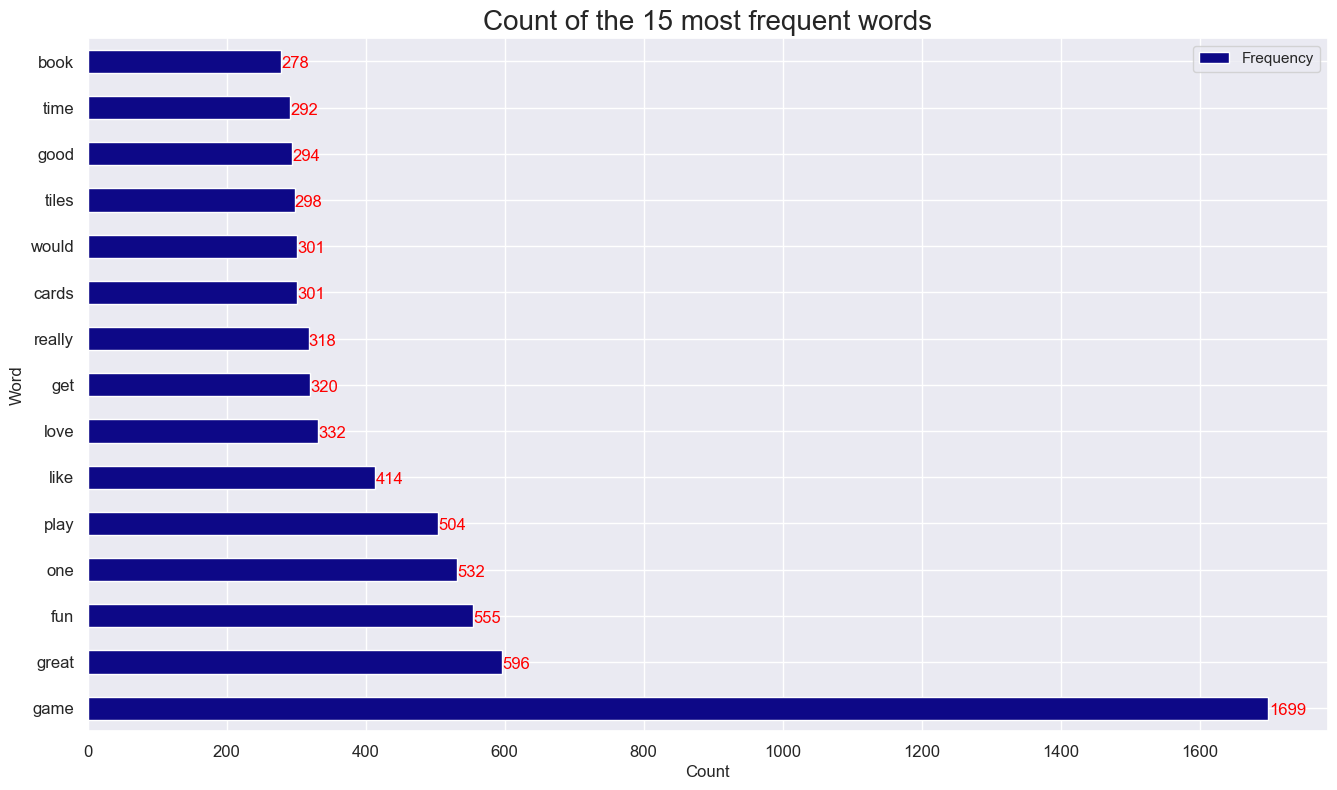

In [72]:
# Set the plot type.
ax = counts.plot(kind='barh', figsize=(16, 9), fontsize=12,
                 colormap ='plasma')

# Set the labels.
ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Word', fontsize=12)
ax.set_title("Count of the 15 most frequent words",
             fontsize=20)

# Draw the bar labels.
for i in ax.patches:
    ax.text(i.get_width()+.41, i.get_y()+.1, str(round((i.get_width()), 2)),
            fontsize=12, color='red')